In [5]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider
from scipy.ndimage import gaussian_filter1d

plt.rcParams['savefig.dpi'] = 300

def compute_exact_density_and_mode(a, sigma, b=1, phase=0.0, grid_res=500, num_theta=200, num_rays=500, t=1.0):
    theta     = np.linspace(0, 2 * np.pi, num_theta)
    r_true    = 1 + (b / a) * np.sin(a * theta + phase)
    dr_dtheta = np.cos(a * theta + phase)

    x_c = t * r_true * np.cos(theta)
    y_c = t * r_true * np.sin(theta)

    ds = np.sqrt(r_true**2 + dr_dtheta**2)
    total_arc_length = np.trapezoid(ds, x=theta)

    limit = 2.0
    x_span = np.linspace(-limit, limit, grid_res)
    y_span = np.linspace(-limit, limit, grid_res)
    X, Y = np.meshgrid(x_span, y_span)

    density_grid = np.zeros_like(X)
    for i in range(grid_res):
        X_row = X[i, :][..., np.newaxis]
        Y_row = Y[i, :][..., np.newaxis]
        sq_dist = (X_row - x_c)**2 + (Y_row - y_c)**2
        integrand = np.exp(-sq_dist / (2 * sigma**2)) * ds
        density_grid[i, :] = np.trapezoid(integrand, x=theta, axis=-1) / (2 * np.pi * sigma**2 * total_arc_length)

    phi    = np.linspace(0, 2 * np.pi, num_rays)
    R_span = np.linspace(0, limit * 0.95, grid_res)
    PHI, R_grid = np.meshgrid(phi, R_span)
    X_ray = R_grid * np.cos(PHI)
    Y_ray = R_grid * np.sin(PHI)

    density_ray = np.zeros_like(X_ray)
    for i in range(grid_res):
        X_r_row = X_ray[i, :][..., np.newaxis]
        Y_r_row = Y_ray[i, :][..., np.newaxis]
        sq_dist_ray = (X_r_row - x_c)**2 + (Y_r_row - y_c)**2
        integrand_ray = np.exp(-sq_dist_ray / (2 * sigma**2)) * ds
        density_ray[i, :] = np.trapezoid(integrand_ray, x=theta, axis=-1)

    idx_c = np.clip(np.argmax(density_ray, axis=0), 1, grid_res - 2)
    j = np.arange(num_rays)
    y0_, y1_, y2_ = density_ray[idx_c - 1, j], density_ray[idx_c, j], density_ray[idx_c + 1, j]
    denom  = y0_ - 2 * y1_ + y2_
    offset = np.where(np.abs(denom) > 1e-30, 0.5 * (y0_ - y2_) / denom, 0.0)
    R_mode = R_span[idx_c] + offset * (R_span[1] - R_span[0])
    R_mode = gaussian_filter1d(R_mode, sigma=num_rays / 200, mode='wrap')

    x_mode = R_mode * np.cos(phi)
    y_mode = R_mode * np.sin(phi)

    return X, Y, density_grid, x_c, y_c, x_mode, y_mode


%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import VBox, HBox

def compute_local_properties(x0, y0, a, sigma, b=1, phase=0.0, num_theta=1000, t=1.0):
    theta = np.linspace(0, 2 * np.pi, num_theta)
    r_true = 1 + (b / a) * np.sin(a * theta + phase)
    x_c = t * r_true * np.cos(theta)
    y_c = t * r_true * np.sin(theta)

    dist_sq = (x_c - x0)**2 + (y_c - y0)**2
    weights = np.exp(-dist_sq / (2 * sigma**2))
    weights /= np.sum(weights)

    y_mean = np.array([np.sum(weights * x_c), np.sum(weights * y_c)])
    score_raw = (y_mean - np.array([x0, y0])) / (sigma**2)
    score_mag = np.linalg.norm(score_raw)
    score_unit = score_raw / score_mag if score_mag > 1e-9 else score_raw

    E_yyT = np.array([[np.sum(weights * x_c**2), np.sum(weights * x_c * y_c)],
                      [np.sum(weights * x_c * y_c), np.sum(weights * y_c**2)]])
    cov = E_yyT - np.outer(y_mean, y_mean)
    jacobian = (1 / sigma**4) * cov - (1 / sigma**2) * np.eye(2)
    eigenvalues, eigenvectors = np.linalg.eigh(jacobian)

    return score_raw, score_unit, eigenvectors, eigenvalues


state = {'x': 0.25, 'y': 1.2}

a_slider     = widgets.IntSlider(  value=8,   min=2,    max=16,      step=1,         description='a')
t_slider     = widgets.FloatLogSlider(value=0.1, base=10, min=-5, max=0, step=0.05, description='1-t')
b_slider     = widgets.FloatSlider(value=1,   min=0,    max=2,       step=0.01,      description='b')
phase_slider = widgets.FloatSlider(value=0.0, min=0.0,  max=2*np.pi, step=np.pi/100, description='φ')

plt.ioff()
fig, ax = plt.subplots(figsize=(9, 9))
fig.canvas.toolbar_visible = False

def inv_max_curvature_curve(x, y):
    dx  = np.gradient(x);  dy  = np.gradient(y)
    ddx = np.gradient(dx); ddy = np.gradient(dy)
    kappa = np.abs(dx * ddy - dy * ddx) / (dx**2 + dy**2)**1.5
    return 1.0 / np.max(kappa)

def inv_max_curvature_polar(a, b, phase, num_theta=5000):
    theta = np.linspace(0, 2 * np.pi, num_theta)
    r   =  1 + (b / a) * np.sin(a * theta + phase)
    dr  =  np.cos(a * theta + phase)
    ddr = -a * np.sin(a * theta + phase)
    kappa = np.abs(r**2 + 2*dr**2 - r*ddr) / (r**2 + dr**2)**1.5
    return 1.0 / np.max(kappa)

def redraw():
    a     = a_slider.value
    b     = b_slider.value
    t     = 1 - t_slider.value
    phase = phase_slider.value
    sigma = np.sqrt(max(1 - t**2, 1e-4))
    x0, y0 = state['x'], state['y']

    X, Y, exact_density, x_true, y_true, x_mode, y_mode = compute_exact_density_and_mode(
        a, sigma, b, phase=phase, num_rays=2000, t=t)
    score, score_unit, eigvecs, eigvals = compute_local_properties(x0, y0, a, sigma, b, phase=phase, t=t)

    for i in range(2):
        if np.dot(eigvecs[:, i], score_unit) < 0:
            eigvecs[:, i] *= -1

    ax.cla()
    ax.pcolormesh(X, Y, exact_density, shading='auto', cmap='viridis', alpha=0.5)
    ax.plot(x_true, y_true, color='black', linewidth=1, label='True curve $C$')
    ax.plot(np.append(x_mode, x_mode[0]), np.append(y_mode, y_mode[0]),
            color='red', linewidth=2, label='Mode curve $M$')

    L = 0.3

    def unit_toward(tx, ty):
        v = np.array([tx - x0, ty - y0])
        n = np.linalg.norm(v)
        return v / n if n > 1e-9 else v

    idx_true = np.argmin((x_true - x0)**2 + (y_true - y0)**2)
    d_true = unit_toward(x_true[idx_true], y_true[idx_true])
    ax.annotate("", xy=(x0 + L * d_true[0], y0 + L * d_true[1]), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color='black', alpha=0.5, lw=2), zorder=5)

    idx_mode = np.argmin((x_mode - x0)**2 + (y_mode - y0)**2)
    d_mode = unit_toward(x_mode[idx_mode], y_mode[idx_mode])
    ax.annotate("", xy=(x0 + L * d_mode[0], y0 + L * d_mode[1]), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color='red', alpha=0.5, lw=2), zorder=5)

    ax.quiver(x0, y0, score_unit[0], score_unit[1], color='white', alpha=1,
              scale=1/L, scale_units='xy', label='Score Dir', zorder=3)
    ax.quiver(x0, y0, eigvecs[0, 0], eigvecs[1, 0], color='cyan', alpha=0.5,
              scale=1/L, scale_units='xy', label='Eig1 Dir', zorder=4)
    ax.quiver(x0, y0, eigvecs[0, 1], eigvecs[1, 1], color='magenta', alpha=0.5,
              scale=1/L, scale_units='xy', label='Eig2 Dir', zorder=4)

    roc_true = inv_max_curvature_polar(a, b, phase)
    roc_mode = inv_max_curvature_curve(x_mode, y_mode)

    ax.set_aspect('equal')
    ax.set_title(
        f"t: {t:.2f}  σ_t: {sigma:.3f}  Score Mag: {np.linalg.norm(score):.2f} | λ₁: {eigvals[0]:.2f}, λ₂: {eigvals[1]:.2f}\n"
        f"1/κ_max — true: {roc_true:.3f}  mode: {roc_mode:.3f}"
    )

    handles, labels = ax.get_legend_handles_labels()
    unique_entries = dict(zip(labels, handles))
    ax.legend(unique_entries.values(), unique_entries.keys(), loc='upper right', frameon=True)

    fig.canvas.draw_idle()


def on_click(event):
    if event.inaxes == ax:
        state['x'], state['y'] = event.xdata, event.ydata
        redraw()

fig.canvas.mpl_connect('button_press_event', on_click)

for sl in [a_slider, t_slider, b_slider, phase_slider]:
    sl.observe(lambda _: redraw(), names='value')

display(VBox([a_slider, t_slider, b_slider, phase_slider, fig.canvas]))
redraw()


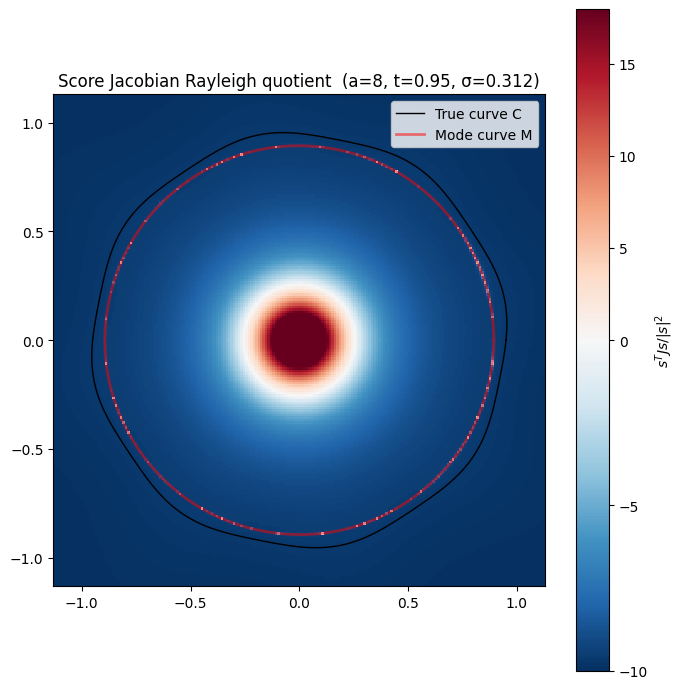

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from IPython.display import display

plt.close('all')
plt.ioff()

a, t, b, phase = 8, 0.95, 0.1, 0.0
sigma = np.sqrt(1 - t**2)
grid_res = 200
limit = 1.125

x_span = np.linspace(-limit, limit, grid_res)
y_span = np.linspace(-limit, limit, grid_res)
X, Y = np.meshgrid(x_span, y_span)
Z = np.full_like(X, np.nan)

for i, y0 in enumerate(y_span):
    for j, x0 in enumerate(x_span):
        score_raw, _, eigvecs, eigvals = compute_local_properties(x0, y0, a, sigma, b, phase, t=t)
        s2 = np.dot(score_raw, score_raw)
        if s2 < 1e-12:
            continue
        J = eigvecs @ np.diag(eigvals) @ eigvecs.T
        Z[i, j] = np.dot(score_raw, J @ score_raw) / s2

vmin, vmax = np.nanpercentile(Z, 1), np.nanpercentile(Z, 99)
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=max(vmax, 1e-3))

theta = np.linspace(0, 2 * np.pi, 1000)
r_true = 1 + (b / a) * np.sin(a * theta + phase)
x_true = t * r_true * np.cos(theta)
y_true = t * r_true * np.sin(theta)

_, _, _, _, _, x_mode, y_mode = compute_exact_density_and_mode(a, sigma, b, phase=phase, num_rays=2000, t=t)

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.pcolormesh(X, Y, Z, shading='auto', cmap='RdBu_r', norm=norm)
ax.plot(x_true, y_true, color='black', linewidth=1, label='True curve C')
ax.plot(np.append(x_mode, x_mode[0]), np.append(y_mode, y_mode[0]),
        color='red', linewidth=2, alpha=0.5, label='Mode curve M')
plt.colorbar(im, ax=ax, label=r'$s^T J s / |s|^2$')
ax.set_aspect('equal')
ax.set_title(f'Score Jacobian Rayleigh quotient  (a={a}, t={t}, σ={sigma:.3f})', fontsize=12)
ax.legend(loc='upper right')
fig.tight_layout()
display(fig)
plt.close(fig)


In [11]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import VBox

plt.ioff()

a, b, phase = 8, 1, 0.0
n_samples = 2000

fig, ax = plt.subplots(figsize=(8, 4))

def compute_and_draw(one_minus_t):
    t       = 1 - one_minus_t
    sigma_t = np.sqrt(max(1 - t**2, 1e-4))
    rng = np.random.default_rng(42)

    num_theta = 10_000
    theta = np.linspace(0, 2 * np.pi, num_theta)
    r_true = 1 + (b / a) * np.sin(a * theta + phase)
    dr_dtheta = np.cos(a * theta + phase)
    ds = np.sqrt(r_true**2 + dr_dtheta**2)
    cdf = np.cumsum(ds)
    cdf /= cdf[-1]
    u = rng.uniform(0, 1, n_samples)
    idx = np.searchsorted(cdf, u)
    theta_s = theta[np.clip(idx, 0, num_theta - 1)]

    r_s = 1 + (b / a) * np.sin(a * theta_s + phase)
    x0 = r_s * np.cos(theta_s)
    y0 = r_s * np.sin(theta_s)

    z = rng.normal(0, 1, (n_samples, 2))
    x_s = t * x0 + sigma_t * z[:, 0]
    y_s = t * y0 + sigma_t * z[:, 1]

    rayleigh = np.empty(n_samples)
    for k in range(n_samples):
        score_raw, _, eigvecs, eigvals = compute_local_properties(x_s[k], y_s[k], a, sigma_t, b, phase, t=t)
        s2 = np.dot(score_raw, score_raw)
        if s2 < 1e-12:
            rayleigh[k] = np.nan
            continue
        J = eigvecs @ np.diag(eigvals) @ eigvecs.T
        rayleigh[k] = np.dot(score_raw, J @ score_raw) / s2

    rayleigh = rayleigh[~np.isnan(rayleigh)]

    ax.cla()
    ax.hist(rayleigh, bins=80, color='steelblue', edgecolor='none', density=True)
    ax.axvline(0, color='red', linewidth=1, linestyle='--', label='0')
    ax.axvline(np.mean(rayleigh), color='orange', linewidth=1.5,
               label=f'mean = {np.mean(rayleigh):.3f}')
    ax.axvline(np.median(rayleigh), color='purple', linewidth=1.5, linestyle='--',
               label=f'median = {np.median(rayleigh):.3f}')
    ax.axvline(np.percentile(rayleigh, 95), color='red', linewidth=1, linestyle='-.',
               label=f'p95 = {np.percentile(rayleigh, 95):.3f}')
    ax.axvline(-1 / sigma_t**2, color='green', linewidth=1, linestyle=':',
               label=f'$-1/\\sigma_t^2$ = {-1/sigma_t**2:.3f}')
    empirical   = np.min(rayleigh)
    theoretical = -1 / sigma_t**2 + 0.5 * t
    pct_diff    = (empirical - theoretical) / abs(theoretical) * 100
    with out:
        out.clear_output(wait=True)
        print(f'min Rayleigh:  {empirical:.6f}')
        print(f'theoretical:   {theoretical:.6f}  (-1/σ²  + t/2)')
        print(f'empirical vs theoretical: {pct_diff:+.2f}%')
    ax.set_xlabel(r'$s^T J s / |s|^2$')
    ax.set_ylabel('density')
    ax.set_title(f'Rayleigh quotient histogram  (a={a}, t={t:.2f}, σ_t={sigma_t:.3f}, n={len(rayleigh)})')
    ax.legend()
    fig.tight_layout()
    fig.canvas.draw_idle()

out = widgets.Output()

t_slider = widgets.FloatLogSlider(value=0.1, base=10, min=-5, max=0, step=0.05,
                                  description='1-t', continuous_update=True)
t_slider.observe(lambda change: compute_and_draw(change['new']), names='value')

display(VBox([t_slider, fig.canvas, out]))
compute_and_draw(t_slider.value)
